<a href="https://colab.research.google.com/github/olblinova/python_for_ds_tasks-is-available/blob/main/%22HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [23]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

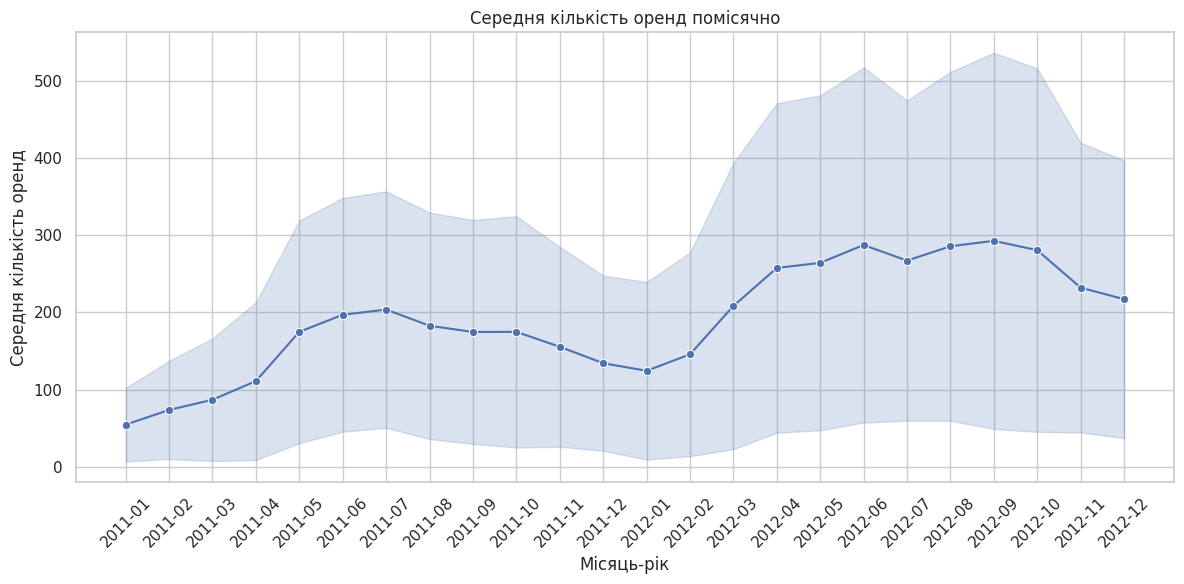

In [29]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    estimator='mean',
    errorbar='sd',
    marker='o',
    )

plt.title('Середня кількість оренд помісячно')
plt.xlabel('Місяць-рік')
plt.ylabel('Середня кількість оренд')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Найбільша невизначеність в даних в графіку червень-жовтень 2012р. Це означає, що в ці місяці кількість оренд по днях/годинах сильно коливалась - від дуже низьких до дуже високих значень.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

In [30]:
n_bins = 20

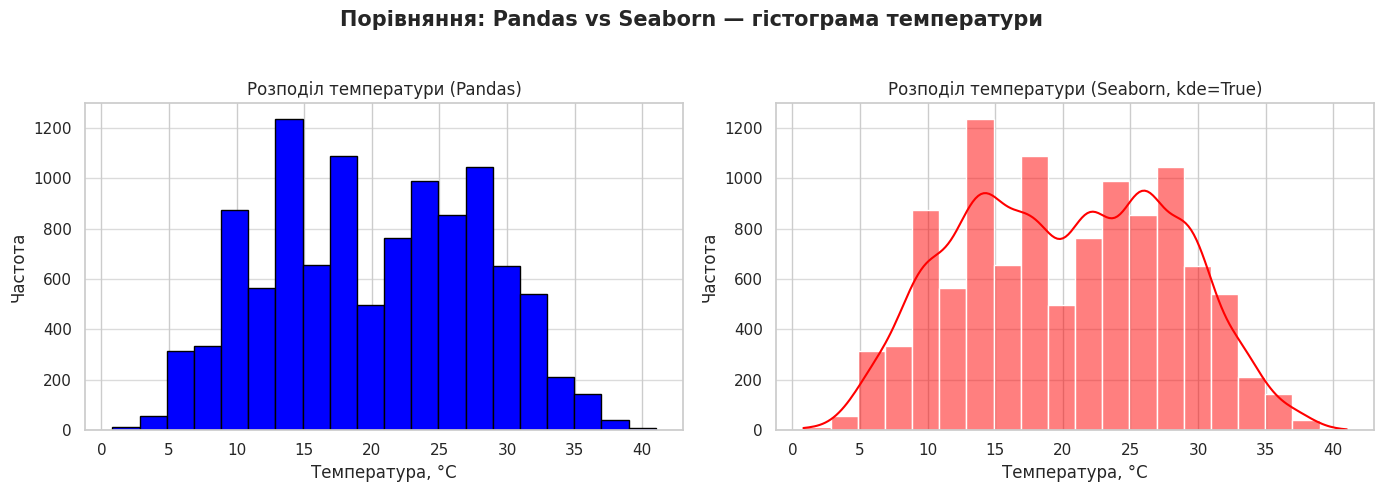

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

df['temp'].plot(
    kind='hist',
    bins=n_bins,
    ax=axs[0],
    color='blue',
    edgecolor='black'
)
axs[0].set_title('Розподіл температури (Pandas)')
axs[0].set_xlabel('Температура, °C')
axs[0].set_ylabel('Частота')
axs[0].grid(True, axis='y', alpha=0.7)

sns.histplot(
    data=df,
    x='temp',
    bins=n_bins,
    kde=True,
    color='red',
    ax=axs[1]
)
axs[1].set_title('Розподіл температури (Seaborn, kde=True)')
axs[1].set_xlabel('Температура, °C')
axs[1].set_ylabel('Частота')
axs[1].grid(True, axis='y', alpha=0.7)

fig.suptitle('Порівняння: Pandas vs Seaborn — гістограма температури', fontsize=15, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


В Pandas гістограма суцільно синя, без прозорості, чіткі чорні межі стовпчиків, тоді як Seaborn напівпрозора, світліша і є лінія kde, що робить її більш "м'якшою" для сприйняття. Крива kde показує чітко, що розподіл температури бімодальний, тобто є два піки популярності температур, а не один.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [40]:
weather_map = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}
df['weather_label'] = df['weather'].map(weather_map)

In [42]:
weather_order = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

In [46]:
df['weather_label'] = pd.Categorical(df['weather_label'], categories=weather_order, ordered=True)

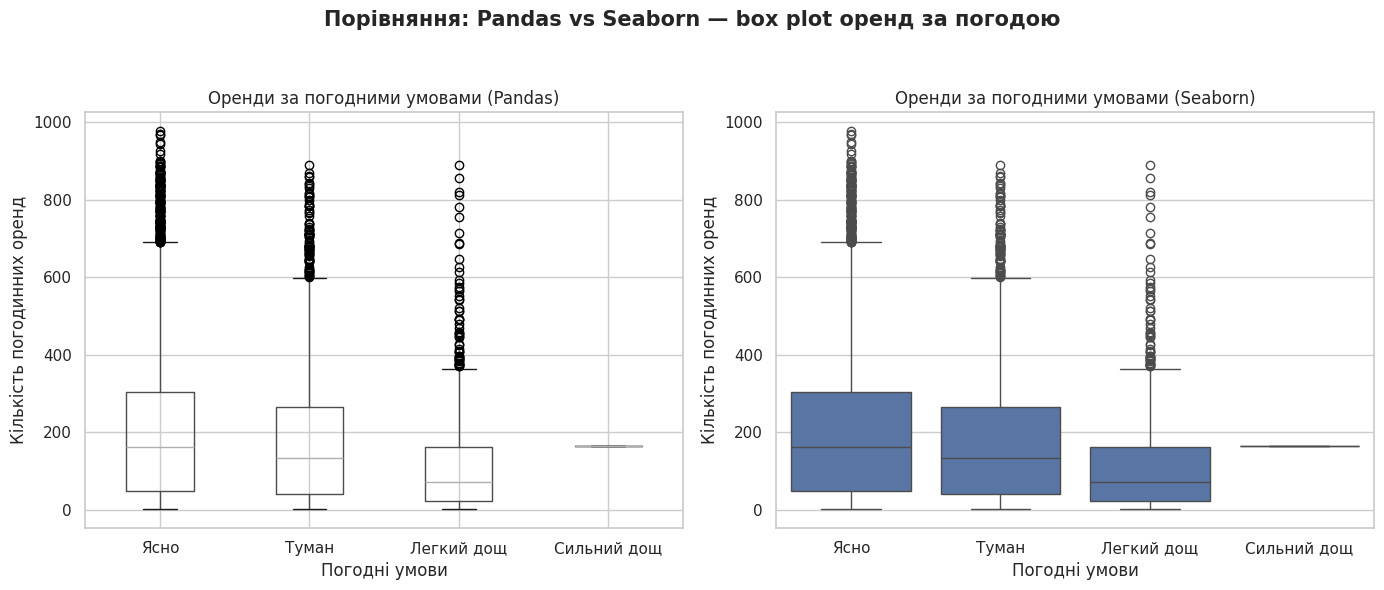

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# з Pandas
df.boxplot(
    column='count',
    by='weather_label',
    ax=axs[0]
)
fig.suptitle('')
axs[0].set_title('Оренди за погодними умовами (Pandas)')
axs[0].set_xlabel('Погодні умови')
axs[0].set_ylabel('Кількість погодинних оренд')
axs[0].set_xticks(range(1, len(weather_order) + 1))
axs[0].set_xticklabels(weather_order)

# з Seaborn
sns.boxplot(
    data=df,
    x='weather_label',
    y='count',
    order=weather_order,
    ax=axs[1]
)
axs[1].set_title('Оренди за погодними умовами (Seaborn)')
axs[1].set_xlabel('Погодні умови')
axs[1].set_ylabel('Кількість погодинних оренд')
axs[1].tick_params(axis='x')

fig.suptitle('Порівняння: Pandas vs Seaborn — box plot оренд за погодою', fontsize=15, fontweight='bold')

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Графік у Seaborn виглядає більш презентабельно,бокси мають синю заливку, більш чіткі, меньше зайвого шуму. В Pandas також досить функціональний графік

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [53]:
# Відбір лише числових колонок та обчислення кореляційної матриці
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

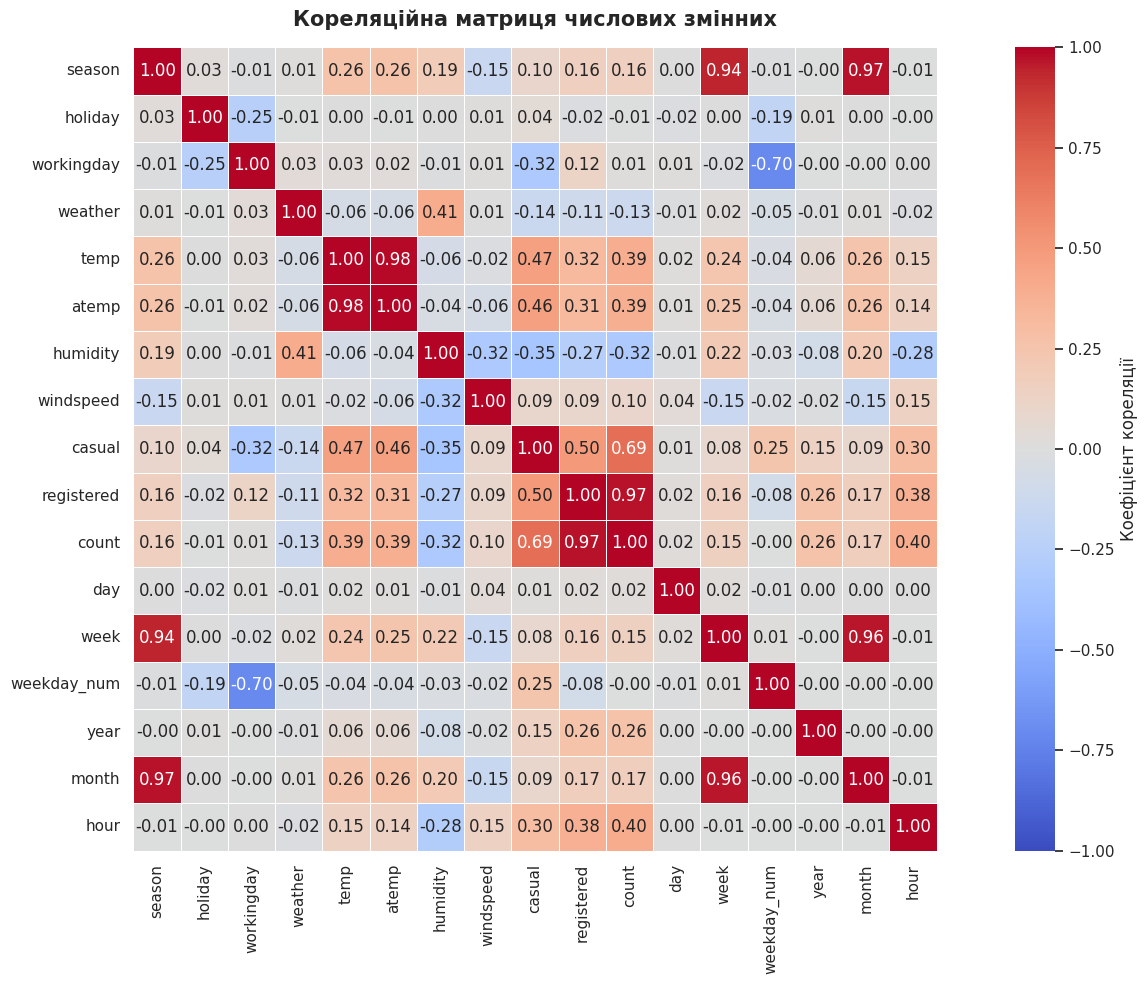

In [57]:
plt.figure(figsize=(16, 10))

sns.heatmap(
    corr_matrix,
    annot=True,          # показати значення в клітинках
    fmt='.2f',            # округлення до 2 знаків
    cmap='coolwarm',      # колірна схема: сині - негативна, червоні - позитивна кореляція
    vmin=-1, vmax=1,      # фіксований діапазон, щоб колір відповідав реальній величині
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Коефіцієнт кореляції'}
)

plt.title('Кореляційна матриця числових змінних', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

1. Найсильніша кореляція з count: registered (0.97) і casual (0.69). З незалежних факторів найпомітніші hour (0.40) і temp/atemp (0.39).

2. temp і atemp: 0.98 - майже ідеальна кореляція, бо atemp рахується на основі temp (з поправкою на вологість/вітер), тобто це, по суті, та сама величина.

3. Негативна кореляція: найсильніша — workingday і weekday_num. Також помітні: humidity з windspeed, casual і count - вища вологість знижує попит і швидкість вітру.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


In [58]:
# Підписи кварталів замість числових кодів 1-4
quarter_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
df['season_label'] = df['season'].map(quarter_map)

In [59]:
quarter_order = ['Q1', 'Q2', 'Q3', 'Q4']
df['season_label'] = pd.Categorical(df['season_label'], categories=quarter_order, ordered=True)

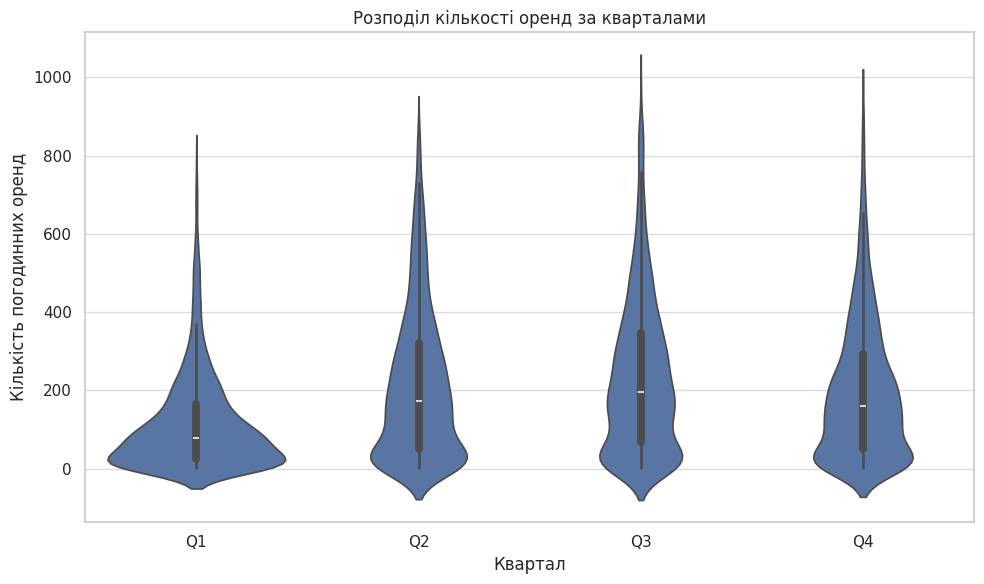

In [65]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='season_label',
    y='count',
    order=quarter_order,
   )

plt.title('Розподіл кількості оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість погодинних оренд')
plt.grid(True, axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

1. Товщина показує щільність розподілу даних. Чим ширша скрипка на певному рівні count, тим більше спостережень має приблизно таке значення оренди.
2. За графіком найбільша варіабельність спостерігається у Q3 (3-му кварталі)
3. Violin plot, на відміну від box plot, показує форму та щільність усього розподілу даних. Тому можна побачити, де саме концентруються значення та як виглядає розподіл, а box plot переважно показує медіану, квартилі та викиди

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

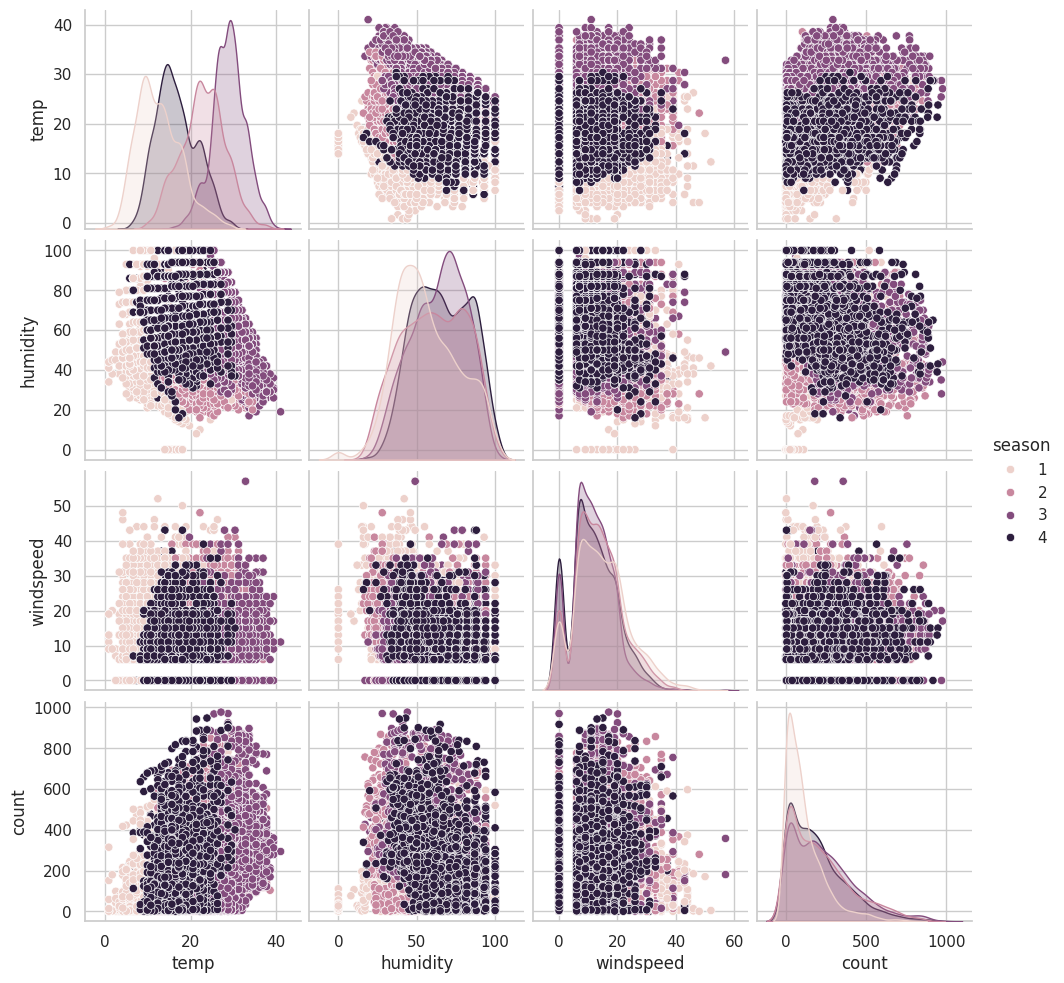

In [75]:
sns.pairplot(
    df[['temp', 'humidity', 'windspeed', 'count', 'season']],
    hue='season',
    diag_kind='kde'
)

plt.show()

1. Найсильніший лінійний зв'язок спостерігається між temp (температурою) та count (кількістю оренд). Зв'язок позитивний: зі зростанням температури кількість оренд загалом збільшується.

2. Найбільше між кварталами відрізняється temp (температура), оскільки сезони мають різні температурні умови: у теплі періоди температура вища, у холодні — нижча.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

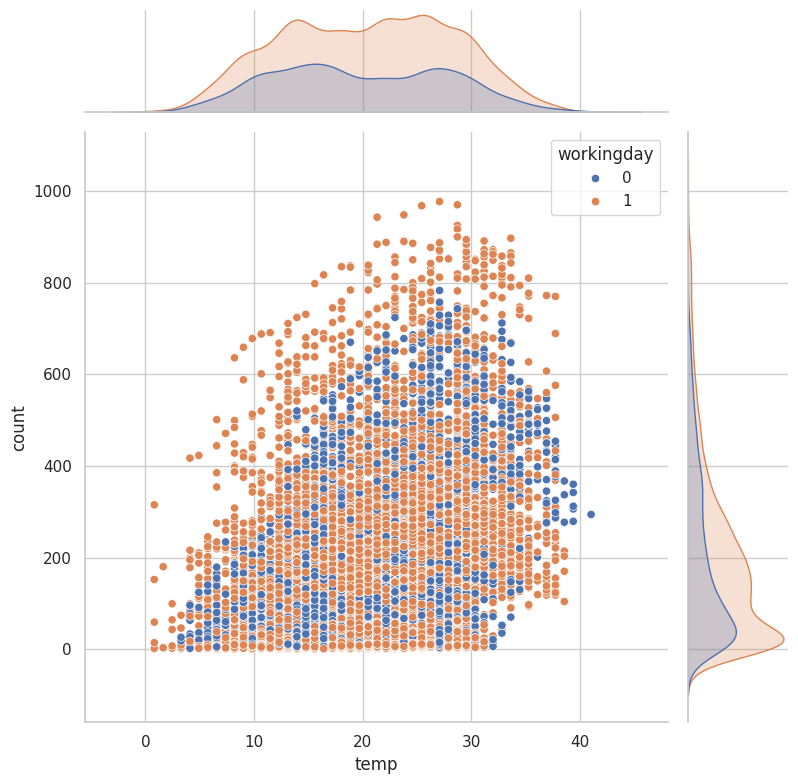

In [67]:
sns.jointplot(
    data=df,
    x='temp',
    y='count',
    hue='workingday',
    kind='scatter',
    height=8
)

plt.show()


1. Графіки по краях показують окремі розподіли температури та кількості оренд.
2.  У робочі дні спостерігається більше високих значень кількості оренд, тоді як у неробочі дні оренда частіше має нижчі та середні значення. В обох випадках зі зростанням температури кількість оренд загалом збільшується.